<a href="https://colab.research.google.com/github/MiniMaliZ/Sistem-Rekomendasi-Kost/blob/main/02_Backward_Chaining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Sistem Rekomendasi Kos — Backward Chaining

**Mata Kuliah:** Sistem Berbasis Pengetahuan  
**Politeknik Negeri Malang — Jurusan Teknologi Informasi**

---

Notebook ini mengimplementasikan **Backward Chaining** untuk sistem rekomendasi kos.

### Perbedaan Forward vs Backward Chaining:
| | Forward Chaining | Backward Chaining |
|---|---|---|
| Arah | Fakta → Kesimpulan | Hipotesis/Goal → Cari Fakta |
| Mulai dari | Data (input) | Goal (target kesimpulan) |
| Cocok untuk | Monitoring, klasifikasi | Diagnosis, verifikasi hipotesis |

> **Pada Backward Chaining**: Pengguna memiliki **goal** (misal: _"Apakah kos X cocok untuk saya?"_ atau _"Saya ingin kos Premium, mana yang tersedia?"_), lalu sistem membuktikan/menyangkal hipotesis itu.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
print('Library siap!')

Library siap!


## 📂 Load & Preprocessing Data
> Upload file `Mamikos_Jabodetabek_Data.xlsx`

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mamikos Jabodetabek Data.xlsx to Mamikos Jabodetabek Data.xlsx


In [4]:
df_raw = pd.read_excel('Mamikos Jabodetabek Data.xlsx')

def parse_price(p):
    cleaned = re.sub(r'[Rp.\s]', '', str(p))
    try: return int(cleaned)
    except: return np.nan

def parse_rating(r):
    if str(r).strip() == 'Not found': return np.nan
    try: return float(r)
    except: return np.nan

def parse_room_size(s):
    match = re.search(r'([\d.]+)\s*[xX]\s*([\d.]+)', str(s))
    if match: return float(match.group(1)) * float(match.group(2))
    return np.nan

def has_facility(fac_str, keyword):
    return 1 if keyword.lower() in str(fac_str).lower() else 0

df = df_raw.copy()
df['price_numeric'] = df['price'].apply(parse_price)
df['rating_numeric'] = df['rating'].apply(parse_rating)
df['rating_numeric'] = df['rating_numeric'].fillna(df['rating_numeric'].median())
df['room_size_m2'] = df['room_size'].apply(parse_room_size)
df['room_size_m2'] = df['room_size_m2'].fillna(df['room_size_m2'].median())
df['electricity_included'] = df['is_electricity_included'].apply(lambda x: 1 if 'termasuk' in str(x).lower() else 0)

for col, kw in [('has_ac','AC'),('has_wifi','WiFi'),('has_private_bathroom','K. Mandi Dalam'),
                ('has_parking','Parkir'),('has_cctv','CCTV'),('has_laundry','Laundry'),
                ('has_kitchen','Dapur'),('has_wardrobe','Lemari Baju'),('has_bed','Kasur')]:
    df[col] = df['all_facilities_bs'].apply(lambda x: has_facility(x, kw))

df['total_facilities'] = df[['has_ac','has_wifi','has_private_bathroom','has_parking',
                              'has_cctv','has_laundry','has_kitchen','has_wardrobe','has_bed']].sum(axis=1)

def kat_harga(h):
    if h < 1_000_000: return 'murah'
    elif h < 2_000_000: return 'sedang'
    elif h < 3_500_000: return 'mahal'
    return 'sangat_mahal'

def kat_rating(r):
    if r >= 4.5: return 'sangat_baik'
    elif r >= 4.0: return 'baik'
    elif r >= 3.0: return 'cukup'
    return 'kurang'

def kat_ukuran(m2):
    if m2 >= 16: return 'luas'
    elif m2 >= 9: return 'sedang'
    return 'sempit'

def kat_fasilitas(t):
    if t >= 7: return 'lengkap'
    elif t >= 4: return 'standar'
    return 'minim'

df['kategori_harga'] = df['price_numeric'].apply(kat_harga)
df['kategori_rating'] = df['rating_numeric'].apply(kat_rating)
df['kategori_ukuran'] = df['room_size_m2'].apply(kat_ukuran)
df['kategori_fasilitas'] = df['total_facilities'].apply(kat_fasilitas)

df = df.dropna(subset=['price_numeric'])
df = df[df['price_numeric'] > 0].reset_index(drop=True)
print(f'Data siap: {df.shape}')

Data siap: (2485, 35)


## 🔁 BACKWARD CHAINING

### Konsep & Arsitektur

Backward Chaining bekerja **dari goal/hipotesis** ke belakang untuk mencari fakta pendukung:

```
GOAL: "Kos ini adalah Kos Premium"
  └── Butuh bukti: harga mahal/sangat_mahal?
        └── Ya → Butuh bukti: rating sangat_baik?
              └── Ya → Butuh bukti: fasilitas lengkap?
                    └── Ya → GOAL TERBUKTI ✓
                    └── Tidak → GOAL GAGAL ✗
```

### Definisi Goal Hierarchy (Tree of Goals)

In [5]:
# ======================================================
# GOAL BASE — Hierarki tujuan untuk Backward Chaining
# ======================================================

# Setiap goal memiliki sub-goals (kondisi yang harus dipenuhi)
# Sistem membuktikan goal dari atas ke bawah (rekursif)

GOAL_TREE = {
    'Kos Premium': {
        'deskripsi': 'Kos mewah dengan harga tinggi, rating excellent, dan fasilitas lengkap',
        'sub_goals': [
            {'field': 'kategori_harga', 'values': ['mahal', 'sangat_mahal']},
            {'field': 'kategori_rating', 'values': ['sangat_baik']},
            {'field': 'kategori_fasilitas', 'values': ['lengkap']},
        ],
        'bobot_rekomendasi': 5,
        'min_match': 3  # harus terpenuhi semua
    },
    'Kos Fasilitas Lengkap': {
        'deskripsi': 'Kos dengan fasilitas standar atau lengkap, rating baik',
        'sub_goals': [
            {'field': 'kategori_fasilitas', 'values': ['lengkap', 'standar']},
            {'field': 'kategori_rating', 'values': ['baik', 'sangat_baik']},
            {'field': 'has_wifi', 'values': [1]},
        ],
        'bobot_rekomendasi': 4,
        'min_match': 3
    },
    'Value for Money': {
        'deskripsi': 'Harga terjangkau namun rating dan fasilitas cukup baik',
        'sub_goals': [
            {'field': 'kategori_harga', 'values': ['murah', 'sedang']},
            {'field': 'kategori_rating', 'values': ['baik', 'sangat_baik']},
            {'field': 'kategori_fasilitas', 'values': ['standar', 'lengkap']},
        ],
        'bobot_rekomendasi': 4,
        'min_match': 2  # cukup 2 dari 3
    },
    'Cocok untuk Mahasiswi': {
        'deskripsi': 'Kos putri dengan WiFi, harga sedang',
        'sub_goals': [
            {'field': 'tipe_kos', 'values': ['Kos Putri']},
            {'field': 'kategori_harga', 'values': ['murah', 'sedang']},
            {'field': 'has_wifi', 'values': [1]},
        ],
        'bobot_rekomendasi': 4,
        'min_match': 3
    },
    'Cocok untuk Profesional': {
        'deskripsi': 'AC, WiFi, kamar mandi dalam, keamanan CCTV',
        'sub_goals': [
            {'field': 'has_ac', 'values': [1]},
            {'field': 'has_wifi', 'values': [1]},
            {'field': 'has_private_bathroom', 'values': [1]},
            {'field': 'has_cctv', 'values': [1]},
        ],
        'bobot_rekomendasi': 4,
        'min_match': 3  # 3 dari 4
    },
    'Kos Aman & Nyaman': {
        'deskripsi': 'CCTV, listrik termasuk, fasilitas baik',
        'sub_goals': [
            {'field': 'has_cctv', 'values': [1]},
            {'field': 'electricity_included', 'values': [1]},
            {'field': 'kategori_fasilitas', 'values': ['standar', 'lengkap']},
        ],
        'bobot_rekomendasi': 3,
        'min_match': 2
    },
    'Cocok untuk Mahasiswa Budget': {
        'deskripsi': 'Harga murah dengan fasilitas dasar (kasur, parkir)',
        'sub_goals': [
            {'field': 'kategori_harga', 'values': ['murah']},
            {'field': 'has_bed', 'values': [1]},
            {'field': 'has_parking', 'values': [1]},
        ],
        'bobot_rekomendasi': 3,
        'min_match': 2
    },
}

print(f'Total Goal dalam GOAL TREE: {len(GOAL_TREE)}')
for gname, gdef in GOAL_TREE.items():
    print(f'  - {gname}: {len(gdef["sub_goals"])} sub-goals, min_match={gdef["min_match"]}')

Total Goal dalam GOAL TREE: 7
  - Kos Premium: 3 sub-goals, min_match=3
  - Kos Fasilitas Lengkap: 3 sub-goals, min_match=3
  - Value for Money: 3 sub-goals, min_match=2
  - Cocok untuk Mahasiswi: 3 sub-goals, min_match=3
  - Cocok untuk Profesional: 4 sub-goals, min_match=3
  - Kos Aman & Nyaman: 3 sub-goals, min_match=2
  - Cocok untuk Mahasiswa Budget: 3 sub-goals, min_match=2


### Implementasi Backward Chaining Engine

In [6]:
def prove_sub_goal(row, sub_goal):
    """
    Coba buktikan satu sub-goal terhadap sebuah baris data.
    Mengembalikan (True/False, field, expected, actual)
    """
    field = sub_goal['field']
    expected = sub_goal['values']

    if field not in row.index:
        return False, field, expected, 'KOLOM_TIDAK_ADA'

    actual = row[field]
    proved = actual in expected
    return proved, field, expected, actual


def backward_chaining_prove_goal(row, goal_name, goal_def, verbose=False):
    """
    Backward Chaining: Coba buktikan goal_name untuk sebuah baris kos.

    Algoritma:
    1. Mulai dari GOAL (hipotesis)
    2. Cari sub-goals yang harus dipenuhi
    3. Buktikan setiap sub-goal dari data (database / fakta)
    4. Jika semua min_match terpenuhi → GOAL PROVEN
    """
    sub_goals = goal_def['sub_goals']
    min_match = goal_def['min_match']

    if verbose:
        print(f'  [BC] Membuktikan GOAL: "{goal_name}"')
        print(f'  [BC] Diperlukan {min_match} dari {len(sub_goals)} sub-goals')

    proved_count = 0
    proof_trace = []

    for sg in sub_goals:
        ok, field, expected, actual = prove_sub_goal(row, sg)
        symbol = '✓' if ok else '✗'
        proof_trace.append(f'{symbol} {field}={actual} (expected: {expected})')
        if ok:
            proved_count += 1

        if verbose:
            print(f'    Sub-goal: {field} in {expected} → actual={actual} [{symbol}]')

    goal_proved = proved_count >= min_match

    if verbose:
        status = 'TERBUKTI ✓' if goal_proved else 'TIDAK TERBUKTI ✗'
        print(f'  [BC] GOAL "{goal_name}": {status} ({proved_count}/{len(sub_goals)} terpenuhi)\n')

    return goal_proved, proved_count, len(sub_goals), proof_trace


def backward_chaining_engine(df, goal_tree, target_goal=None):
    """
    Jalankan Backward Chaining untuk seluruh dataset.
    Jika target_goal diberikan, hanya buktikan goal tersebut.
    """
    results = []
    goals_to_check = {target_goal: goal_tree[target_goal]} if target_goal else goal_tree

    for idx, row in df.iterrows():
        best_goal = 'Tidak Direkomendasikan'
        best_bobot = 0
        best_match_ratio = 0
        proved_goals = []

        for gname, gdef in goals_to_check.items():
            proved, count, total, trace = backward_chaining_prove_goal(row, gname, gdef)
            match_ratio = count / total

            if proved:
                proved_goals.append(gname)
                if gdef['bobot_rekomendasi'] > best_bobot:
                    best_bobot = gdef['bobot_rekomendasi']
                    best_goal = gname
                    best_match_ratio = match_ratio

        bc_score = best_bobot * best_match_ratio if proved_goals else 0

        results.append({
            'idx': idx,
            'bc_label': best_goal,
            'bc_score': round(bc_score, 3),
            'bc_proved_goals': ', '.join(proved_goals) if proved_goals else 'Tidak ada',
            'bc_goals_count': len(proved_goals)
        })

    return pd.DataFrame(results).set_index('idx')


print('Menjalankan Backward Chaining...')
bc_results = backward_chaining_engine(df, GOAL_TREE)
print('Selesai!')
print()
print('=== Distribusi Label Rekomendasi (Backward Chaining) ===')
print(bc_results['bc_label'].value_counts())

Menjalankan Backward Chaining...
Selesai!

=== Distribusi Label Rekomendasi (Backward Chaining) ===
bc_label
Kos Fasilitas Lengkap           1597
Kos Premium                      507
Value for Money                  353
Tidak Direkomendasikan            15
Cocok untuk Profesional            8
Cocok untuk Mahasiswa Budget       4
Kos Aman & Nyaman                  1
Name: count, dtype: int64


### Demo: Pembuktian Goal untuk Kos Spesifik (Verbose)

In [7]:
# Ambil satu baris contoh dan tunjukkan proses pembuktian detail
contoh_kos = df.iloc[5]
print(f'=== DEMO BACKWARD CHAINING ===')
print(f'Kos: {contoh_kos["room_name"]}')
print(f'Region: {contoh_kos["region"]}')
print(f'Harga: {contoh_kos["price_numeric"]:,}')
print(f'Rating: {contoh_kos["rating_numeric"]}')
print(f'Tipe: {contoh_kos["tipe_kos"]}')
print(f'AC: {contoh_kos["has_ac"]}, WiFi: {contoh_kos["has_wifi"]}, Kamar Mandi Dalam: {contoh_kos["has_private_bathroom"]}')
print()

# Uji semua goal secara verbose
for gname, gdef in GOAL_TREE.items():
    proved, count, total, trace = backward_chaining_prove_goal(contoh_kos, gname, gdef, verbose=True)

=== DEMO BACKWARD CHAINING ===
Kos: Kost 21 Alam Sutera Tipe B Serpong Utara Tangerang Selatan
Region: Tangerang Selatan
Harga: 2,200,000
Rating: 4.8
Tipe: Kos Putra
AC: 1, WiFi: 1, Kamar Mandi Dalam: 0

  [BC] Membuktikan GOAL: "Kos Premium"
  [BC] Diperlukan 3 dari 3 sub-goals
    Sub-goal: kategori_harga in ['mahal', 'sangat_mahal'] → actual=mahal [✓]
    Sub-goal: kategori_rating in ['sangat_baik'] → actual=sangat_baik [✓]
    Sub-goal: kategori_fasilitas in ['lengkap'] → actual=lengkap [✓]
  [BC] GOAL "Kos Premium": TERBUKTI ✓ (3/3 terpenuhi)

  [BC] Membuktikan GOAL: "Kos Fasilitas Lengkap"
  [BC] Diperlukan 3 dari 3 sub-goals
    Sub-goal: kategori_fasilitas in ['lengkap', 'standar'] → actual=lengkap [✓]
    Sub-goal: kategori_rating in ['baik', 'sangat_baik'] → actual=sangat_baik [✓]
    Sub-goal: has_wifi in [1] → actual=1 [✓]
  [BC] GOAL "Kos Fasilitas Lengkap": TERBUKTI ✓ (3/3 terpenuhi)

  [BC] Membuktikan GOAL: "Value for Money"
  [BC] Diperlukan 2 dari 3 sub-goals
    Sub

### Fungsi Konsultasi: Tanyakan Goal Spesifik

In [8]:
def konsultasi_backward_chaining(df, goal_tree, goal_target, filter_region=None, filter_tipe=None,
                                   budget_max=None, top_n=10):
    """
    Backward Chaining: Cari kos yang memenuhi goal_target tertentu.
    Pengguna mulai dari TUJUAN, sistem membuktikannya.
    """
    if goal_target not in goal_tree:
        print(f'Goal "{goal_target}" tidak ditemukan!')
        print(f'Goal tersedia: {list(goal_tree.keys())}')
        return None

    df_filtered = df.copy()
    if filter_region:
        df_filtered = df_filtered[df_filtered['region'].str.contains(filter_region, case=False, na=False)]
    if filter_tipe:
        df_filtered = df_filtered[df_filtered['tipe_kos'] == filter_tipe]
    if budget_max:
        df_filtered = df_filtered[df_filtered['price_numeric'] <= budget_max]

    gdef = goal_tree[goal_target]
    results = []

    for idx, row in df_filtered.iterrows():
        proved, count, total, trace = backward_chaining_prove_goal(row, goal_target, gdef)
        if proved:
            results.append({
                'room_name': row['room_name'],
                'region': row['region'],
                'tipe_kos': row['tipe_kos'],
                'price_numeric': row['price_numeric'],
                'rating_numeric': row['rating_numeric'],
                'total_facilities': row['total_facilities'],
                'bc_match_ratio': f'{count}/{total}',
                'bc_proof': ' | '.join(trace)
            })

    if not results:
        print(f'Tidak ditemukan kos yang membuktikan goal: "{goal_target}"')
        return pd.DataFrame()

    result_df = pd.DataFrame(results).sort_values('rating_numeric', ascending=False)
    print(f'Ditemukan {len(result_df)} kos yang membuktikan goal: "{goal_target}"')
    return result_df.head(top_n)


# ===================================
# CONTOH 1: Saya ingin Kos Premium
# ===================================
print('=== KONSULTASI 1: Kos Premium di Jakarta Selatan ===')
hasil_1 = konsultasi_backward_chaining(
    df, GOAL_TREE,
    goal_target='Kos Premium',
    filter_region='Jakarta Selatan',
    top_n=5
)
if hasil_1 is not None and not hasil_1.empty:
    print(hasil_1[['room_name','region','price_numeric','rating_numeric','bc_match_ratio']].to_string())

=== KONSULTASI 1: Kos Premium di Jakarta Selatan ===
Ditemukan 127 kos yang membuktikan goal: "Kos Premium"
                                                                 room_name           region  price_numeric  rating_numeric bc_match_ratio
1                    Kost Apik Puri Rinda Tipe A Jagakarsa Jakarta Selatan  Jakarta Selatan        2685000             5.0            3/3
22  Kost Singgahsini Bella Swadarma VI Tipe A Pesanggrahan Jakarta Selatan  Jakarta Selatan        2590000             5.0            3/3
35    Kost Singgahsini Cherry Suites Tipe B Kebayoran Baru Jakarta Selatan  Jakarta Selatan        3700000             5.0            3/3
42   Kost Singgahsini Dito Jati Padang Tipe C Pasar Minggu Jakarta Selatan  Jakarta Selatan        2225000             5.0            3/3
72                    Kost Singgahsini Maroon Tipe A Tebet Jakarta Selatan  Jakarta Selatan        2185000             5.0            3/3


In [9]:
# ===================================
# CONTOH 2: Kos untuk Mahasiswi
# ===================================
print('=== KONSULTASI 2: Kos untuk Mahasiswi Budget ≤ Rp1.800.000 di Depok ===')
hasil_2 = konsultasi_backward_chaining(
    df, GOAL_TREE,
    goal_target='Cocok untuk Mahasiswi',
    filter_region='Depok',
    budget_max=1_800_000,
    top_n=5
)
if hasil_2 is not None and not hasil_2.empty:
    print(hasil_2[['room_name','region','price_numeric','rating_numeric','total_facilities','bc_match_ratio']].to_string())

=== KONSULTASI 2: Kos untuk Mahasiswi Budget ≤ Rp1.800.000 di Depok ===
Ditemukan 101 kos yang membuktikan goal: "Cocok untuk Mahasiswi"
                                        room_name region  price_numeric  rating_numeric  total_facilities bc_match_ratio
20     Kost Apik Siti Fadila UI Tipe A Beji Depok  Depok         565000             5.0                 4            3/3
31                  Kost DGreen Tipe A Beji Depok  Depok        1800000             5.0                 7            3/3
82    Kost Singgahsini Homey Beji Tipe C UI Depok  Depok        1080000             5.0                 6            3/3
99                          Kost Zahra Beji Depok  Depok        1400000             5.0                 7            3/3
55  Kost Pondok Fanay Standard Pancoran Mas Depok  Depok        1500000             5.0                 8            3/3


In [10]:
# ===================================
# CONTOH 3: Value for Money
# ===================================
print('=== KONSULTASI 3: Value for Money di Bekasi ===')
hasil_3 = konsultasi_backward_chaining(
    df, GOAL_TREE,
    goal_target='Value for Money',
    filter_region='Bekasi',
    top_n=5
)
if hasil_3 is not None and not hasil_3.empty:
    print(hasil_3[['room_name','region','price_numeric','rating_numeric','bc_match_ratio']].to_string())

=== KONSULTASI 3: Value for Money di Bekasi ===
Ditemukan 314 kos yang membuktikan goal: "Value for Money"
                                                                           room_name  region  price_numeric  rating_numeric bc_match_ratio
279                                  Kost Syariah Asri Hijau Cikarang Selatan Bekasi  Bekasi         750000             5.0            3/3
276                                           Kost Sr Tipe VIP Cikarang Barat Bekasi  Bekasi        1150000             5.0            3/3
30      Kost Bvly Safehouse CoLiving Pet Friendly Double Bed Cikarang Selatan Bekasi  Bekasi        3500000             5.0            2/3
29   Kost Bvly Safehouse CoLiving Pet Friendly Deluxe Studio Cikarang Selatan Bekasi  Bekasi        2800000             5.0            2/3
26                                                Kost Bu Ulfa Tambun Selatan Bekasi  Bekasi        1200000             5.0            3/3


### Full Dataset Scoring & Visualisasi

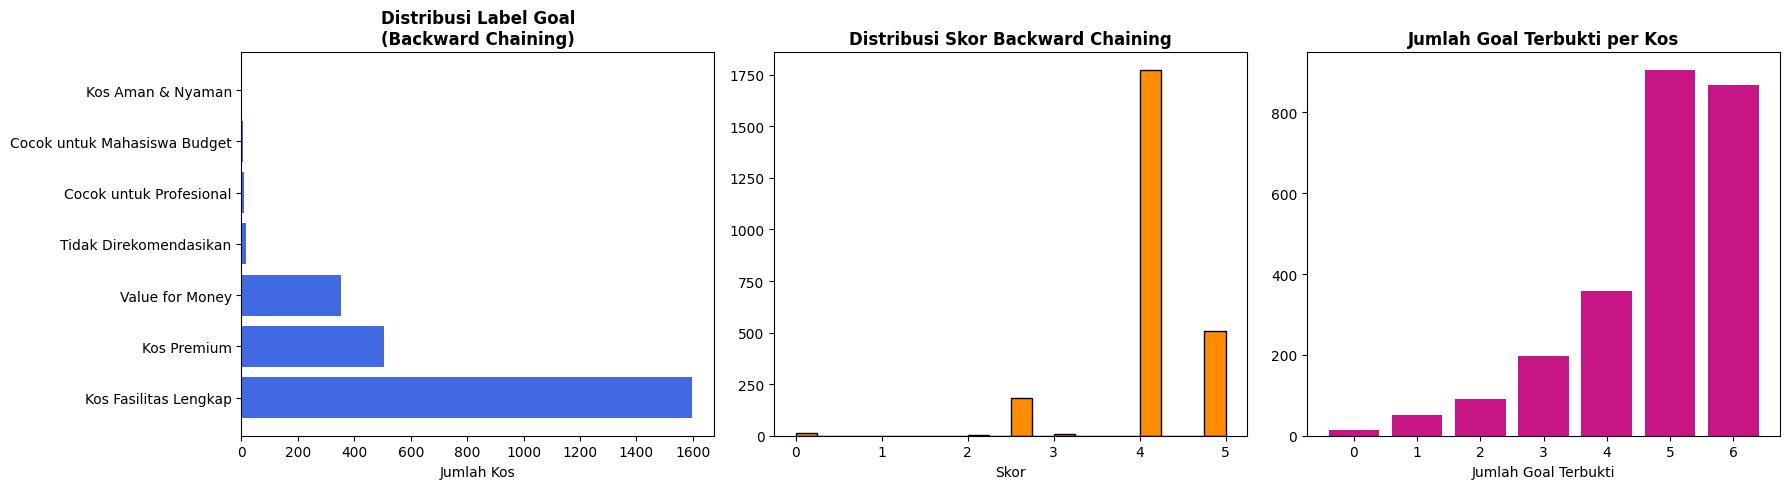

Visualisasi tersimpan!


In [11]:
df_bc = df.copy().join(bc_results)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribusi Label
label_counts = df_bc['bc_label'].value_counts()
axes[0].barh(label_counts.index, label_counts.values, color='royalblue')
axes[0].set_title('Distribusi Label Goal\n(Backward Chaining)', fontweight='bold')
axes[0].set_xlabel('Jumlah Kos')

# Plot 2: Distribusi Skor BC
axes[1].hist(df_bc['bc_score'], bins=20, color='darkorange', edgecolor='black')
axes[1].set_title('Distribusi Skor Backward Chaining', fontweight='bold')
axes[1].set_xlabel('Skor')

# Plot 3: Jumlah goal terbukti per kos
gc = df_bc['bc_goals_count'].value_counts().sort_index()
axes[2].bar(gc.index, gc.values, color='mediumvioletred')
axes[2].set_title('Jumlah Goal Terbukti per Kos', fontweight='bold')
axes[2].set_xlabel('Jumlah Goal Terbukti')

plt.tight_layout()
plt.savefig('backward_chaining_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi tersimpan!')

### Ringkasan & Analisis

In [12]:
print('=' * 60)
print('RINGKASAN BACKWARD CHAINING')
print('=' * 60)
print(f'Total data kos       : {len(df_bc)}')
print(f'Total goal di tree   : {len(GOAL_TREE)}')
direk = df_bc[df_bc['bc_label'] != 'Tidak Direkomendasikan']
print(f'Kos goal terbukti    : {len(direk)} ({len(direk)/len(df_bc)*100:.1f}%)')
print()
print('Top 5 Kos (Skor BC Tertinggi):')
print(df_bc.nlargest(5, 'bc_score')[['room_name','region','price_numeric','rating_numeric','bc_score','bc_label']].to_string())
print()
print('Kelebihan Backward Chaining:')
print('  - Efisien: hanya mengevaluasi fakta yang relevan dengan goal')
print('  - Cocok untuk diagnosis/konsultasi (user punya target spesifik)')
print('  - Trace pembuktian transparan')
print()
print('Keterbatasan Backward Chaining:')
print('  - Perlu definisi goal tree yang tepat')
print('  - Kurang cocok untuk eksplorasi terbuka tanpa goal')
print('  - Tidak ada penanganan ketidakpastian bawaan')

RINGKASAN BACKWARD CHAINING
Total data kos       : 2485
Total goal di tree   : 7
Kos goal terbukti    : 2470 (99.4%)

Top 5 Kos (Skor BC Tertinggi):
                                                      room_name             region  price_numeric  rating_numeric  bc_score     bc_label
5    Kost 21 Alam Sutera Tipe B Serpong Utara Tangerang Selatan  Tangerang Selatan        2200000             4.8       5.0  Kos Premium
7           Kost 2nd Home Tipe Executive Palmerah Jakarta Barat      Jakarta Barat        3100000             5.0       5.0  Kos Premium
10  Kost 3tranches Home Senopati Kebayoran Baru Jakarta Selatan    Jakarta Selatan        3800000             4.6       5.0  Kos Premium
14           Kost 93 Suites Primier Tanjung Priok Jakarta Utara      Jakarta Utara        3500000             4.8       5.0  Kos Premium
15        Kost 93 Suites Standart 2 Tanjung Priok Jakarta Utara      Jakarta Utara        2200000             5.0       5.0  Kos Premium

Kelebihan Backward Chaining: